In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy

plt.style.use("ICIWstyle")

In [ ]:
n_dot = np.load("MGA-E-13032025_120ml-min_1atm_heated_TotalSystem_MS_composition.npy")
timestamps = np.load("MGA-E-13032025_120ml-min_1atm_heated_TotalSystem_MS_times.npy")

In [ ]:
time_delta = timestamps - timestamps[0]

np.savez(
    "MGA-E-13032025_120ml-min_1atm_heated_TotalSystem.npz",
    n_dot=n_dot,
    time_delta=time_delta,
)

t_range = (time_delta.min(), time_delta.max())

In [12]:
t_offset = 7.4 - 1
t_halfperiod = 120.0

switching_times = np.full((20,), t_halfperiod)
switching_times = np.insert(switching_times, 0, t_offset)
switching_times = np.cumsum(switching_times)
print(switching_times)

intervals = [
    (switching_times[i], switching_times[i + 1])
    for i in range(len(switching_times) - 1)
]
print(intervals)

[   6.4  126.4  246.4  366.4  486.4  606.4  726.4  846.4  966.4 1086.4
 1206.4 1326.4 1446.4 1566.4 1686.4 1806.4 1926.4 2046.4 2166.4 2286.4
 2406.4]
[(6.4, 126.4), (126.4, 246.4), (246.4, 366.4), (366.4, 486.4), (486.4, 606.4), (606.4, 726.4), (726.4, 846.4), (846.4, 966.4), (966.4, 1086.4), (1086.4, 1206.4), (1206.4, 1326.4), (1326.4, 1446.4), (1446.4, 1566.4), (1566.4, 1686.4), (1686.4, 1806.4), (1806.4, 1926.4), (1926.4, 2046.4), (2046.4, 2166.4), (2166.4, 2286.4), (2286.4, 2406.4)]


In [13]:
interp = scipy.interpolate.interp1d(
    time_delta,
    n_dot,
    kind="linear",
    fill_value="extrapolate",
)

In [14]:
t = np.linspace(*t_range, 10000)
n_dot_interp = interp(t)

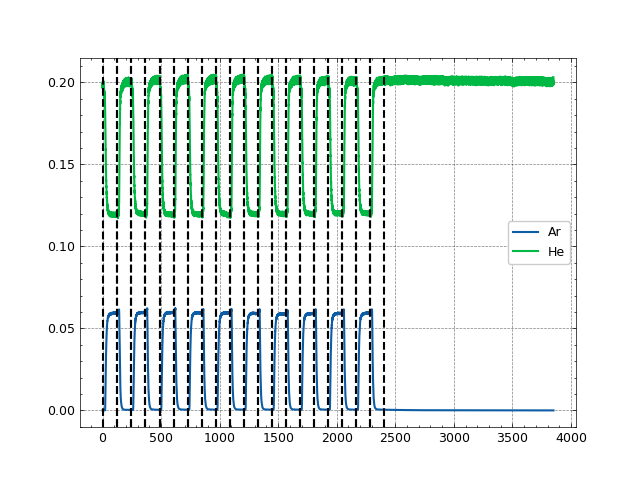

In [15]:
%matplotlib widget
plt.figure()
plt.plot(t, n_dot_interp[0], label="Ar")
plt.plot(t, n_dot_interp[1], label="He")
for interval in intervals:
    plt.axvline(interval[0], color="black", linestyle="--")
    plt.axvline(interval[1], color="black", linestyle="--")
plt.legend()
plt.show()

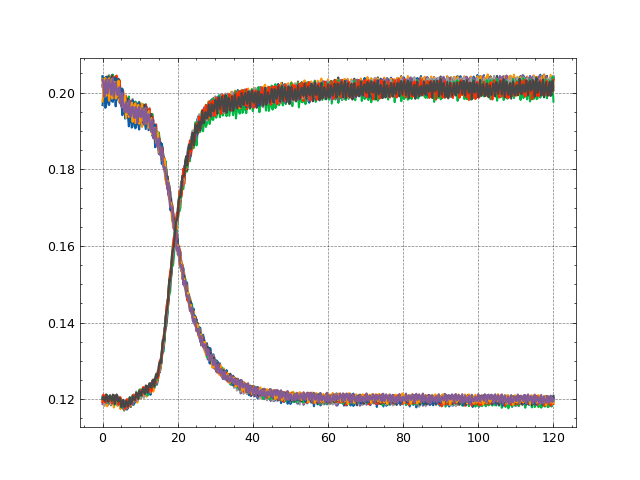

In [16]:
fig = plt.figure()
for interval in intervals:

    t = np.linspace(interval[0], interval[0] + 120, 480 + 1)

    n_dot_interp = interp(t)

    plt.plot(t - interval[0], n_dot_interp[1])
plt.show()